In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

BENCHMARK_DATA = joinpath(ROOT, "example_notebooks", "benchmark_data")
OUTPUT_PDF_DIR = joinpath(ROOT, "output", "pdf")
benchmark_file(parts...) = joinpath(BENCHMARK_DATA, parts...)
mkpath(OUTPUT_PDF_DIR)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using DelimitedFiles
using NPZ
using LsqFit
using JLD2
using Statistics

  Activating project at `~/Desktop/FastDifferentiableMMNLO`


# CP scaling data

In [2]:
mode_numbers = npzread(benchmark_file("cp_rank_scaling", "mode_number_list.npy"));
cp_rank_table_step = npzread(benchmark_file("cp_rank_scaling", "cp_rank_table_step.npy"));
cp_rank_table_grin = npzread(benchmark_file("cp_rank_scaling", "cp_rank_table_grin.npy"));

dense_timing_list_step = npzread(benchmark_file("cp_rank_scaling", "dense_timing_list_step.npy"));
dense_timing_list_grin = npzread(benchmark_file("cp_rank_scaling", "dense_timing_list_grin.npy"));

cp_timing_list_step = npzread(benchmark_file("cp_rank_scaling", "rhs_timing_list_cp_step.npy"));
cp_timing_list_grin = npzread(benchmark_file("cp_rank_scaling", "rhs_timing_list_cp_grin.npy"));

# Perturbed elliptical step-index data.
cp_rank_table_step_perturbed_ellipse = npzread(benchmark_file("cp_rank_scaling", "cp_rank_table_step_perturbed_ellipse.npy"));
dense_timing_list_step_perturbed_ellipse = npzread(benchmark_file("cp_rank_scaling", "dense_timing_list_step_perturbed_ellipse.npy"));
cp_timing_list_step_perturbed_ellipse = npzread(benchmark_file("cp_rank_scaling", "rhs_timing_list_cp_step_perturbed_ellipse.npy"));
xgrid_perturbed_ellipse = npzread(benchmark_file("cp_rank_scaling", "xgrid_perturbed_ellipse.npy"));
index_perturbed_ellipse = npzread(benchmark_file("cp_rank_scaling", "index_perturbed_ellipse.npy"));
first_mode_perturbed_ellipse = npzread(benchmark_file("cp_rank_scaling", "first_mode_perturbed_ellipse.npy"));



## Power-law scaling fits

The rank and RK4IP timing data are fit to $y(x)=y_0+a x^b$ with non-negative parameters. Timing fits minimize relative rather than absolute residuals so that the largest timings do not dominate the regression. A first timing sample is classified as a warm-up outlier only when it exceeds the second sample by more than a factor of 10; excluded samples remain visible as gray crosses. Each column of the CP tables is fit independently. The rank-plot legend reports $b \pm 1\sigma_b$, where $\sigma_b$ is the local least-squares standard error from `LsqFit.stderror`; it measures scatter around the fitted model, but not uncertainty from rank-search discretization or model choice.

In [3]:
power_model(x, p) = @. p[1] + p[2] * x^p[3]

function warmup_inliers(y; factor=10.0)
    keep = trues(length(y))
    if length(y) > 1 && y[1] > factor * y[2]
        keep[1] = false
    end
    keep
end

function power_fit(x, y; b0=1.0, relative=false, inliers=trues(length(y)))
    xfit = Float64.(x[inliers])
    yfit = Float64.(y[inliers])
    y00 = 0.5 * minimum(yfit)
    a0 = (maximum(yfit) - y00) / maximum(xfit)^b0
    p0 = [y00, a0, b0]

    if relative
        weights = 1.0 ./ yfit.^2
        curve_fit(power_model, xfit, yfit, weights, p0; lower=zeros(3))
    else
        curve_fit(power_model, xfit, yfit, p0; lower=zeros(3))
    end
end

fit_parameters(fit) = (; y0=coef(fit)[1], a=coef(fit)[2], b=coef(fit)[3])

function style_scaling_axes!(ax)
    ax.spines["top"].set_visible(false)
    ax.spines["right"].set_visible(false)
    ax.grid(true, which="major", color="#D0D0D0", linewidth=0.6, alpha=0.65)
    ax.tick_params(direction="out", width=0.8)
end

colors = ["#0072B2", "#D55E00", "#009E73"]
timing_colors = [colors..., "#CC79A7"]
markers = ["o", "s", "^"]
cp_labels = ["1e-$j" for j in 2:4]

3-element Vector{String}:
 "1e-2"
 "1e-3"
 "1e-4"

In [4]:
rank_step_fits = [power_fit(mode_numbers, cp_rank_table_step[:, j]; b0=1.0)
                   for j in axes(cp_rank_table_step, 2)]
rank_grin_fits = [power_fit(mode_numbers, cp_rank_table_grin[:, j]; b0=1.0)
                   for j in axes(cp_rank_table_grin, 2)]
rank_perturbed_ellipse_fits = [power_fit(mode_numbers, cp_rank_table_step_perturbed_ellipse[:, j]; b0=1.0)
                   for j in axes(cp_rank_table_step_perturbed_ellipse, 2)]

dense_step_mask = warmup_inliers(dense_timing_list_step)
dense_grin_mask = warmup_inliers(dense_timing_list_grin)
dense_perturbed_ellipse_mask = warmup_inliers(dense_timing_list_step_perturbed_ellipse)
cp_step_masks = [warmup_inliers(cp_timing_list_step[:, j])
                 for j in axes(cp_timing_list_step, 2)]
cp_grin_masks = [warmup_inliers(cp_timing_list_grin[:, j])
                 for j in axes(cp_timing_list_grin, 2)]
cp_perturbed_ellipse_masks = [warmup_inliers(cp_timing_list_step_perturbed_ellipse[:, j])
                 for j in axes(cp_timing_list_step_perturbed_ellipse, 2)]

dense_step_fit = power_fit(mode_numbers, dense_timing_list_step;
    b0=3.0, relative=true, inliers=dense_step_mask)
dense_grin_fit = power_fit(mode_numbers, dense_timing_list_grin;
    b0=3.0, relative=true, inliers=dense_grin_mask)
dense_perturbed_ellipse_fit = power_fit(mode_numbers, dense_timing_list_step_perturbed_ellipse;
    b0=3.0, relative=true, inliers=dense_perturbed_ellipse_mask)
cp_step_fits = [power_fit(mode_numbers, cp_timing_list_step[:, j];
    b0=1.0, relative=true, inliers=cp_step_masks[j])
    for j in axes(cp_timing_list_step, 2)]
cp_grin_fits = [power_fit(mode_numbers, cp_timing_list_grin[:, j];
    b0=1.0, relative=true, inliers=cp_grin_masks[j])
    for j in axes(cp_timing_list_grin, 2)]
cp_perturbed_ellipse_fits = [power_fit(mode_numbers, cp_timing_list_step_perturbed_ellipse[:, j];
    b0=1.0, relative=true, inliers=cp_perturbed_ellipse_masks[j])
    for j in axes(cp_timing_list_step_perturbed_ellipse, 2)]

rank_fit_parameters = (
    step=fit_parameters.(rank_step_fits),
    grin=fit_parameters.(rank_grin_fits),
    perturbed_ellipse=fit_parameters.(rank_perturbed_ellipse_fits),
)
timing_fit_parameters = (
    dense_step=fit_parameters(dense_step_fit),
    dense_grin=fit_parameters(dense_grin_fit),
    dense_perturbed_ellipse=fit_parameters(dense_perturbed_ellipse_fit),
    cp_step=fit_parameters.(cp_step_fits),
    cp_grin=fit_parameters.(cp_grin_fits),
    cp_perturbed_ellipse=fit_parameters.(cp_perturbed_ellipse_fits),
)

(; rank_fit_parameters, timing_fit_parameters)

(rank_fit_parameters = (step = [(y0 = 9.092252348351614, a = 3.8684070465460567, b = 1.0318995798567256), (y0 = 0.0, a = 6.818179520551878, b = 0.9527765248725142), (y0 = 0.0, a = 11.520990891354453, b = 0.8894898215796153)], grin = [(y0 = 0.6820792557618927, a = 5.305167905653773, b = 0.9606936364884235), (y0 = 0.0, a = 7.160388889268967, b = 0.928811425998786), (y0 = 15.942745515339697, a = 7.183981148992977, b = 0.9391868031003103)], perturbed_ellipse = [(y0 = 0.6820792557618927, a = 5.305167905653773, b = 0.9606936364884235), (y0 = 23.672773783701377, a = 5.812357449164714, b = 0.9858896381336651), (y0 = 11.271340059648221, a = 13.778806348072946, b = 0.8875654464344869)]), timing_fit_parameters = (dense_step = (y0 = 0.0011151411368934471, a = 1.3075742677851615e-8, b = 3.793521020996066), dense_grin = (y0 = 0.0012503177982707626, a = 1.0932654612649835e-8, b = 3.833001068593371), dense_perturbed_ellipse = (y0 = 0.001990548313738296, a = 8.457823149612806e-9, b = 3.889028684734332)

### Timing-fit extrapolation

Set `K` to the desired maximum mode count and rerun the next cell. Markers show all measured data; fitted curves extend to `K`. The vertical dotted line marks the largest measured mode count, so everything to its right is extrapolation.

In [5]:
K = 500

function timing_extrapolation_plot(K)
    measured_limit = maximum(mode_numbers)
    K >= measured_limit || error("K must be at least $measured_limit")
    xcurve_K = 10.0 .^ range(log10(minimum(mode_numbers)), log10(K), length=600)

    fig, ax = subplots(figsize=(10, 5))
    dense_color = timing_colors[4]

    # Step-index data and extrapolated fits (solid lines).
    ax.loglog(mode_numbers[dense_step_mask], dense_timing_list_step[dense_step_mask];
        linestyle="none", marker="D", markersize=6.2, markerfacecolor="white",
        markeredgewidth=1.35, color=dense_color, zorder=4)
    ax.loglog(xcurve_K, power_model(xcurve_K, coef(dense_step_fit));
        color=dense_color, linestyle="-", linewidth=2.0,
        label="Step — dense  (b = $(round(coef(dense_step_fit)[3], digits=2)))")

    for j in axes(cp_timing_list_step, 2)
        ax.loglog(mode_numbers[cp_step_masks[j]], cp_timing_list_step[cp_step_masks[j], j];
            linestyle="none", marker=markers[j], markersize=6.2,
            markerfacecolor="white", markeredgewidth=1.35,
            color=timing_colors[j], zorder=4)
        ax.loglog(xcurve_K, power_model(xcurve_K, coef(cp_step_fits[j]));
            color=timing_colors[j], linestyle="-", linewidth=2.0,
            label="Step — ε = $(cp_labels[j])  (b = $(round(coef(cp_step_fits[j])[3], digits=2)))")
    end

    # Retain the measured samples excluded from the fits.
    excluded_x_K = vcat(mode_numbers[.!dense_step_mask],
        [mode_numbers[.!cp_step_masks[j]] for j in axes(cp_timing_list_step, 2)]...)
    excluded_y_K = vcat(dense_timing_list_step[.!dense_step_mask],
        [cp_timing_list_step[.!cp_step_masks[j], j] for j in axes(cp_timing_list_step, 2)]...)
    if !isempty(excluded_x_K)
        ax.loglog(excluded_x_K, excluded_y_K; linestyle="none", marker="x",
            markersize=7.0, markeredgewidth=1.4, color="#8C8C8C",
            label="Excluded warm-up", zorder=5)
    end

    # GRIN data and extrapolated fits (dashed lines).
    ax.loglog(mode_numbers[dense_grin_mask], dense_timing_list_grin[dense_grin_mask];
        linestyle="none", marker="D", markersize=6.2, markerfacecolor="white",
        markeredgewidth=1.35, color=dense_color, zorder=3)
    ax.loglog(xcurve_K, power_model(xcurve_K, coef(dense_grin_fit));
        color=dense_color, linestyle="--", linewidth=2.0,
        label="GRIN — dense  (b = $(round(coef(dense_grin_fit)[3], digits=2)))")

    for j in axes(cp_timing_list_grin, 2)
        ax.loglog(mode_numbers[cp_grin_masks[j]], cp_timing_list_grin[cp_grin_masks[j], j];
            linestyle="none", marker=markers[j], markersize=6.2,
            markerfacecolor="white", markeredgewidth=1.35,
            color=timing_colors[j], zorder=3)
        ax.loglog(xcurve_K, power_model(xcurve_K, coef(cp_grin_fits[j]));
            color=timing_colors[j], linestyle="--", linewidth=2.0,
            label="GRIN — ε = $(cp_labels[j])  (b = $(round(coef(cp_grin_fits[j])[3], digits=2)))")
    end

    ax.axvline(measured_limit; color="#8C8C8C", linestyle=":",
        linewidth=1.2, zorder=1)
    #ax.set_title("RK4IP step-time scaling extrapolated to $(K) modes", pad=10)
    ax.set_xlabel("Number of modes")
    ax.set_ylabel("Single RK4IP step time (s)")
    ax.set_xlim(9, 1.03K)
    style_scaling_axes!(ax)
    ax.spines["top"].set_visible(true)
    ax.spines["right"].set_visible(true)
    ax.grid(true, which="minor", color="#E5E5E5", linewidth=0.4, alpha=0.35)
    ax.legend(frameon=true, loc="upper left", handlelength=3.2,
        labelspacing=0.9, ncol=1, bbox_to_anchor=(0.025, 1.0))
    fig.subplots_adjust(left=0.09, right=0.67, bottom=0.14, top=0.90)
    fig
end

timing_extrapolation_plot (generic function with 1 method)

## Two figure 1 sub-panels

Solid, dashed, and dash-dot curves denote the circular step-index, GRIN, and perturbed elliptical step-index systems, respectively. Filled markers identify the perturbed-ellipse measurements. The rank-panel insets show its index profile and normalized first-mode amplitude $|E|$.

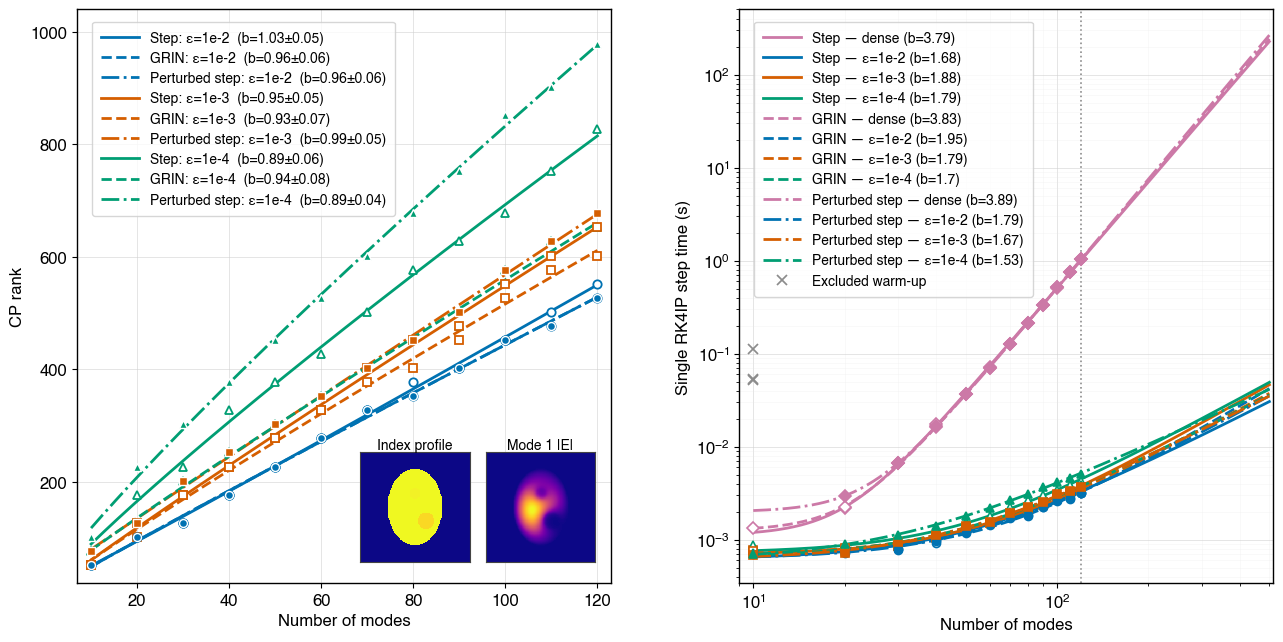

In [6]:
xcurve = range(minimum(mode_numbers), maximum(mode_numbers), length=400)

rc("font", family="Helvetica", size=12)
rc("axes", titlesize=13, labelsize=12, linewidth=1)
rc("xtick", labelsize=12)
rc("ytick", labelsize=12)
rc("legend", fontsize=9.5)

function standalone_rank_plot()
fig_rank, ax_rank = subplots(figsize=(10,5))
for j in axes(cp_rank_table_step, 2)
    ax_rank.plot(mode_numbers, cp_rank_table_step[:, j]; linestyle="none",
        marker=markers[j], markersize=6.2, markerfacecolor="white",
        markeredgewidth=1.35, color=colors[j], zorder=4)
    b_step = coef(rank_step_fits[j])[3]
    σb_step = stderror(rank_step_fits[j])[3]
    ax_rank.plot(xcurve, power_model(xcurve, coef(rank_step_fits[j]));
        color=colors[j], linestyle="-", linewidth=2.0,
        label="Step: ε = $(cp_labels[j])  (b = $(round(b_step, digits=2)) ± $(round(σb_step, digits=2)))")

    ax_rank.plot(mode_numbers, cp_rank_table_grin[:, j]; linestyle="none",
        marker=markers[j], markersize=6.2, markerfacecolor="white",
        markeredgewidth=1.35, color=colors[j], zorder=3)
    b_grin = coef(rank_grin_fits[j])[3]
    σb_grin = stderror(rank_grin_fits[j])[3]
    ax_rank.plot(xcurve, power_model(xcurve, coef(rank_grin_fits[j]));
        color=colors[j], linestyle="--", linewidth=2.0,
        label="GRIN: ε = $(cp_labels[j])  (b = $(round(b_grin, digits=2)) ± $(round(σb_grin, digits=2)))")
end
#ax_rank.set_title("CP-rank scaling", pad=10)
ax_rank.set_xlabel("Number of modes")
ax_rank.set_ylabel("CP rank")
ax_rank.set_xlim(7, 123)
ax_rank.set_ylim(20, 850)
style_scaling_axes!(ax_rank)
ax_rank.spines["top"].set_visible(true)
ax_rank.spines["right"].set_visible(true)
# ax_rank.legend(frameon=true,
#     loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0,
#     handlelength=3.2, labelspacing=0.9)

ax_rank.legend(
    frameon=true,
    loc="upper left",
    handlelength=3.2,
    labelspacing=0.9,
)


fig_rank.subplots_adjust(left=0.09, right=0.67, bottom=0.14, top=0.90)
display(fig_rank)
end

# # Preserve the timing figure's existing typography until its design is approved.
# rc("font", family="sans-serif", size=10)
# rc("axes", titlesize=11, labelsize=10, linewidth=0.8)
# rc("xtick", labelsize=9)
# rc("ytick", labelsize=9)
# rc("legend", fontsize=8.5)

function plot_rank_panel!(ax)
    for j in axes(cp_rank_table_step, 2)
        ax.plot(mode_numbers, cp_rank_table_step[:, j]; linestyle="none",
            marker=markers[j], markersize=6.0, markerfacecolor="white",
            markeredgewidth=1.3, color=colors[j], zorder=5)
        b_step, σb_step = coef(rank_step_fits[j])[3], stderror(rank_step_fits[j])[3]
        ax.plot(xcurve, power_model(xcurve, coef(rank_step_fits[j]));
            color=colors[j], linestyle="-", linewidth=2.0,
            label="Step: ε=$(cp_labels[j])  (b=$(round(b_step, digits=2))±$(round(σb_step, digits=2)))")

        ax.plot(mode_numbers, cp_rank_table_grin[:, j]; linestyle="none",
            marker=markers[j], markersize=6.0, markerfacecolor="white",
            markeredgewidth=1.3, color=colors[j], zorder=4)
        b_grin, σb_grin = coef(rank_grin_fits[j])[3], stderror(rank_grin_fits[j])[3]
        ax.plot(xcurve, power_model(xcurve, coef(rank_grin_fits[j]));
            color=colors[j], linestyle="--", linewidth=2.0,
            label="GRIN: ε=$(cp_labels[j])  (b=$(round(b_grin, digits=2))±$(round(σb_grin, digits=2)))")

        ax.plot(mode_numbers, cp_rank_table_step_perturbed_ellipse[:, j]; linestyle="none",
            marker=markers[j], markersize=5.7, markerfacecolor=colors[j],
            markeredgewidth=1.0, markeredgecolor="white", color=colors[j], zorder=6)
        b_ellipse = coef(rank_perturbed_ellipse_fits[j])[3]
        σb_ellipse = stderror(rank_perturbed_ellipse_fits[j])[3]
        ax.plot(xcurve, power_model(xcurve, coef(rank_perturbed_ellipse_fits[j]));
            color=colors[j], linestyle="-.", linewidth=2.0,
            label="Perturbed step: ε=$(cp_labels[j])  (b=$(round(b_ellipse, digits=2))±$(round(σb_ellipse, digits=2)))")
    end

    ax.set_xlabel("Number of modes")
    ax.set_ylabel("CP rank")
    ax.set_xlim(7, 123)
    ax.set_ylim(20, 1040)
    style_scaling_axes!(ax)
    ax.spines["top"].set_visible(true)
    ax.spines["right"].set_visible(true)
    ax.legend(frameon=true, loc="upper left", handlelength=2.7,
        labelspacing=0.45, columnspacing=0.9, ncol=1, fontsize=10,
        borderpad=0.65, bbox_to_anchor=(0.015, 0.99))
    add_perturbed_profile_insets!(ax)
end

function add_perturbed_profile_insets!(ax)
    extent_um = 1e6 .* [first(xgrid_perturbed_ellipse), last(xgrid_perturbed_ellipse),
        first(xgrid_perturbed_ellipse), last(xgrid_perturbed_ellipse)]
    mode1 = abs.(first_mode_perturbed_ellipse)
    mode1 ./= maximum(mode1)

    ax_index = ax.inset_axes([0.53, 0.03, 0.205, 0.205])
    ax_index.imshow(index_perturbed_ellipse; origin="lower", extent=extent_um,
        cmap="plasma", interpolation="nearest", aspect="equal")
    ax_index.set_title("Index profile", fontsize=10, pad=2.0)

    ax_mode = ax.inset_axes([0.765, 0.03, 0.205, 0.205])
    ax_mode.imshow(mode1; origin="lower", extent=extent_um,
        cmap="plasma", interpolation="nearest", aspect="equal", vmin=0, vmax=1)
    ax_mode.set_title("Mode 1 |E|", fontsize=10, pad=2.0)

    for inset_ax in (ax_index, ax_mode)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        for side in ("left", "right", "bottom", "top")
            inset_ax.spines[side].set_linewidth(0.8)
            inset_ax.spines[side].set_color("#444444")
        end
    end
end

function plot_timing_panel!(ax, K)
    measured_limit = maximum(mode_numbers)
    K >= measured_limit || error("K must be at least $measured_limit")
    xcurve_K = 10.0 .^ range(log10(minimum(mode_numbers)), log10(K), length=600)
    dense_color = timing_colors[4]

    timing_sets = [
        ("Step", "-", "white", dense_timing_list_step, cp_timing_list_step,
            dense_step_mask, cp_step_masks, dense_step_fit, cp_step_fits),
        ("GRIN", "--", "white", dense_timing_list_grin, cp_timing_list_grin,
            dense_grin_mask, cp_grin_masks, dense_grin_fit, cp_grin_fits),
        ("Perturbed step", "-.", "filled", dense_timing_list_step_perturbed_ellipse,
            cp_timing_list_step_perturbed_ellipse, dense_perturbed_ellipse_mask,
            cp_perturbed_ellipse_masks, dense_perturbed_ellipse_fit, cp_perturbed_ellipse_fits)
    ]

    excluded_x_panel = Float64[]
    excluded_y_panel = Float64[]
    for (geometry, line_style, fill_style, dense_data, cp_data, dense_mask, cp_masks, dense_fit, cp_fits) in timing_sets
        dense_face = fill_style == "filled" ? dense_color : "white"
        ax.loglog(mode_numbers[dense_mask], dense_data[dense_mask];
            linestyle="none", marker="D", markersize=5.8, markerfacecolor=dense_face,
            markeredgewidth=1.2, markeredgecolor=dense_color, color=dense_color, zorder=5)
        ax.loglog(xcurve_K, power_model(xcurve_K, coef(dense_fit));
            color=dense_color, linestyle=line_style, linewidth=2.0,
            label="$geometry — dense (b=$(round(coef(dense_fit)[3], digits=2)))")
        append!(excluded_x_panel, mode_numbers[.!dense_mask])
        append!(excluded_y_panel, dense_data[.!dense_mask])

        for j in axes(cp_data, 2)
            face = fill_style == "filled" ? timing_colors[j] : "white"
            ax.loglog(mode_numbers[cp_masks[j]], cp_data[cp_masks[j], j];
                linestyle="none", marker=markers[j], markersize=5.8, markerfacecolor=face,
                markeredgewidth=1.2, markeredgecolor=timing_colors[j],
                color=timing_colors[j], zorder=5)
            ax.loglog(xcurve_K, power_model(xcurve_K, coef(cp_fits[j]));
                color=timing_colors[j], linestyle=line_style, linewidth=2.0,
                label="$geometry — ε=$(cp_labels[j]) (b=$(round(coef(cp_fits[j])[3], digits=2)))")
            append!(excluded_x_panel, mode_numbers[.!cp_masks[j]])
            append!(excluded_y_panel, cp_data[.!cp_masks[j], j])
        end
    end

    if !isempty(excluded_x_panel)
        ax.loglog(excluded_x_panel, excluded_y_panel; linestyle="none", marker="x",
            markersize=6.6, markeredgewidth=1.25, color="#8C8C8C",
            label="Excluded warm-up", zorder=6)
    end

    ax.axvline(measured_limit; color="#8C8C8C", linestyle=":",
        linewidth=1.2, zorder=1)
    ax.set_xlabel("Number of modes")
    ax.set_ylabel("Single RK4IP step time (s)")
    ax.set_xlim(9, 1.03K)
    style_scaling_axes!(ax)
    ax.spines["top"].set_visible(true)
    ax.spines["right"].set_visible(true)
    ax.grid(true, which="minor", color="#E5E5E5", linewidth=0.4, alpha=0.35)
    ax.legend(frameon=true, loc="upper left", handlelength=2.7,
        labelspacing=0.45, columnspacing=0.9, ncol=1, fontsize=10,
        borderpad=0.65, bbox_to_anchor=(0.015, 0.99))
end

fig_figure1, axes_figure1 = subplots(1, 2, figsize=(13,7))
plot_rank_panel!(axes_figure1[1])
plot_timing_panel!(axes_figure1[2], K)
fig_figure1.subplots_adjust(left=0.065, right=0.985, bottom=0.15, top=0.97, wspace=0.24)
savefig(joinpath(OUTPUT_PDF_DIR, "figure1_rank_timing_subpanels.pdf"); bbox_inches="tight", pad_inches=0.05)
display(fig_figure1)

# 1035 mode propagation example

In [13]:
xvals_1035_um = npzread(benchmark_file("1035_mode_benchmark", "xvals_1035modes.npy"));
Ixy_in = npzread(benchmark_file("1035_mode_benchmark", "Iwxy_cp_1035modes_initial.npy"));
Ixy0p1 = npzread(benchmark_file("1035_mode_benchmark", "Iwxy_cp_1035modes_0p1.npy"));
Ixy0p001 = npzread(benchmark_file("1035_mode_benchmark", "Iwxy_cp_1035modes_0p001.npy"));
spec_0p1 = npzread(benchmark_file("1035_mode_benchmark", "spectral_fields_cp_1035modes_0p1.npy"));
spec_0p001 = npzread(benchmark_file("1035_mode_benchmark", "spectral_fields_cp_1035modes_0p001.npy"));
λ_nm1035 = npzread(benchmark_file("1035_mode_benchmark", "wavelengths_1035modes.npy"));

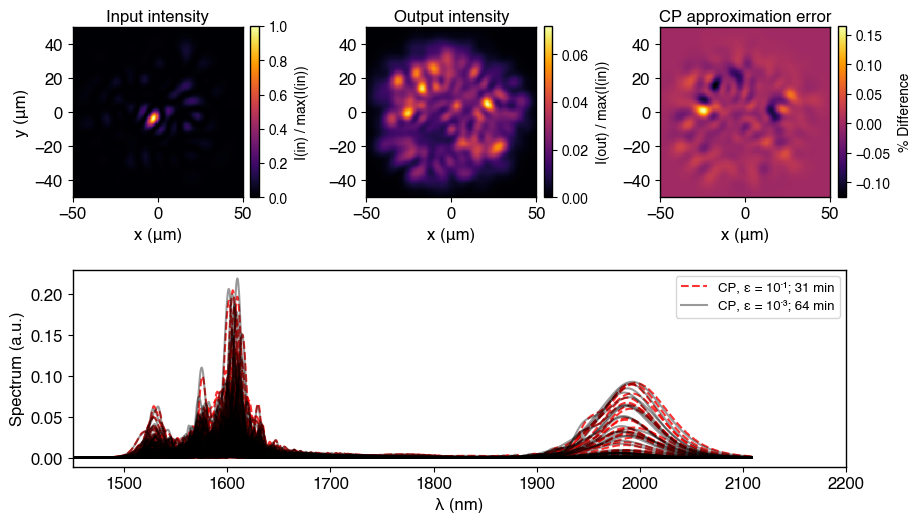

In [14]:
fig_combined = figure(figsize=(8.5, 5.4))

ax_in = subplot2grid((2, 3), (0, 0); fig=fig_combined)
ax_out = subplot2grid((2, 3), (0, 1); fig=fig_combined)
ax_diff = subplot2grid((2, 3), (0, 2); fig=fig_combined)
ax_spec = subplot2grid((2, 3), (1, 0); colspan=3, fig=fig_combined)

spatial_panels = (
    (ax_in, Ixy_in ./ maximum(Ixy_in), "Input intensity", "I(in) / max(I(in))"),
    (ax_out, Ixy0p001 ./ maximum(Ixy_in), "Output intensity", "I(out) / max(I(in))"),
    (ax_diff, (Ixy0p001 - Ixy0p1) ./ maximum(Ixy0p1), "CP approximation error", "% Difference"),
)

for (j, (ax, image_data, panel_title, colorbar_label)) in enumerate(spatial_panels)
    mesh = ax.pcolormesh(xvals_1035_um, xvals_1035_um, image_data;
        cmap="inferno", shading="auto")
    ax.set_title(panel_title; fontsize=12, pad=4)
    ax.set_xlabel("x (μm)")
    j == 1 && ax.set_ylabel("y (μm)")
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_aspect("equal")
    cb = fig_combined.colorbar(mesh; ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(colorbar_label; fontsize=10, labelpad=5)
    cb.ax.tick_params(labelsize=10)
end

cp_lines_0p1_combined = ax_spec.plot(
    λ_nm1035, abs2.(spec_0p1[:, 1:120, 1]);
    linestyle="--", color="red", alpha=0.8,
)
cp_lines_0p001_combined = ax_spec.plot(
    λ_nm1035, abs2.(spec_0p001[:, 1:120, 1]);
    linestyle="-", color="black", alpha=0.4,
)
ax_spec.set_xlim(1450, 2200)
ax_spec.set_xlabel("λ (nm)")
ax_spec.set_ylabel("Spectrum (a.u.)")
ax_spec.legend(
    [cp_lines_0p1_combined[1], cp_lines_0p001_combined[1]],
    ["CP, ε = 10⁻¹; 31 min", "CP, ε = 10⁻³; 64 min"];
    frameon=true, loc="upper right",
)

fig_combined.subplots_adjust(
    left=0.075, right=0.985, bottom=0.11, top=0.95,
    wspace=0.58, hspace=0.30,
)
savefig(joinpath(OUTPUT_PDF_DIR, "figure3_1035modes.pdf"); bbox_inches="tight", pad_inches=0.05)
savefig(joinpath(OUTPUT_PDF_DIR, "figure3_1035modes.png"); dpi=600, bbox_inches="tight", pad_inches=0.05)
display(fig_combined)

Full-field versus cp

In [10]:
λ_ff = npzread(benchmark_file("full_field_versus_modal", "cpff_wavelengths.npy"));
Aω_cp_0p01 = npzread(benchmark_file("full_field_versus_modal", "cpff_spectral_fields_0p01.npy"));
Aω_cp_0p0001 = npzread(benchmark_file("full_field_versus_modal", "cpff_spectral_fields_0p0001.npy"));
Aω_dense = npzread(benchmark_file("full_field_versus_modal", "cpff_spectral_fields_dense.npy"));
Aω_ff = npzread(benchmark_file("full_field_versus_modal", "cpff_spectral_fields_ff.npy"));

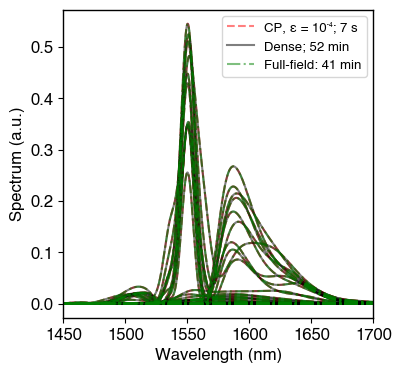

In [11]:
figure(figsize=(4,4))
cp_lines = plot(λ_ff,abs2.(Aω_cp_0p0001[:,:,1]), linestyle="--",color="red",alpha=0.5)
dense_lines = plot(λ_ff,abs2.(Aω_dense[:,:,1]), linestyle="-",color="black",alpha=0.5)
ff_lines = plot(λ_ff,abs2.(Aω_ff[:,:,1]), linestyle="-.",color="green",alpha=0.5)
xlim(1450,1700)
xlabel("Wavelength (nm)")
ylabel("Spectrum (a.u.)")

legend(
    [cp_lines[1], dense_lines[1], ff_lines[1]],
    ["CP, ε = 10⁻⁴; 7 s", "Dense; 52 min", "Full-field: 41 min"];
    frameon=true,
    loc="upper right",
)
savefig(joinpath(OUTPUT_PDF_DIR, "ff_cp_dense.pdf"); bbox_inches="tight", pad_inches=0.05)
display(gcf())

Stochastic trajectories

In [14]:
ensemble = JLD2.load(benchmark_file("stochastic_soliton_jitter", "ensemble.jld2"), "ensemble")
λ_sto = npzread(benchmark_file("stochastic_soliton_jitter", "λ_stochastic.npy"));
t_sto = [-50:100/(2^14 - 1):50;];

In [15]:
ensemble_spec_in = abs2.(get_spectral_field(ensemble;z=:initial));
ensemble_spec_out = abs2.(get_spectral_field(ensemble));

ensemble_t_in = abs2.(get_temporal_field(ensemble;z=:initial));
ensemble_t_out = abs2.(get_temporal_field(ensemble));

average_spec_in = reshape(sum(ensemble_spec_in,dims=4),(2^14,105))/size(ensemble_spec_in,4);
average_spec_out = reshape(sum(ensemble_spec_out,dims=4),(2^14,105))/size(ensemble_spec_out,4);

average_t_in = reshape(sum(ensemble_t_in,dims=4),(2^14,105))/size(ensemble_t_in,4);
average_t_out = reshape(sum(ensemble_t_out,dims=4),(2^14,105))/size(ensemble_t_out,4);

In [16]:
initial_ensemble = MMGNLSEStochasticSolution(
    z=ensemble.z[1:1],
    fields=ensemble.fields[:, :, :, 1:1, :],
    parameters=ensemble.parameters,
    noise=ensemble.noise,
)

MMGNLSEStochasticSolution{Float64, Array{ComplexF64, 5}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, Float64}, Float64, Float64, AnisotropicRaman{Float64}}, @NamedTuple{fano::Array{Float64, 3}, photon_noise::Array{ComplexF64, 4}, weights::Vector{Float64}, seed::Nothing}}([0.0], ComplexF64[-5.093630139208521 + 0.23477720082568265im -3.5691110869174807 - 2.398048942611291im … 2.503676547265075 - 4.070301581213935im 1.9793092183568266 - 0.5968409409538209im; 0.6947727704804905 + 1.6376365325104667im 2.0082944214587073 + 1.1216983494499424im … -5.2423976839843185 - 1.6242944930613268im -0.34831449367739803 + 4.068945044341541im; … ; -3.8344309497386213 - 2.798305863945536im -1.183634467760669 - 2.375654375103343im … -2.00497500399465 + 1.8134450893991774im 1.8866742056113026 - 0.4291433512201476im; -4.719007577553139 + 3.3013327020970795im 1.9787956620348837 - 0.6125752886036

Stochastic illustration

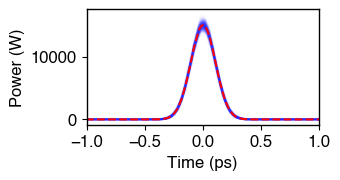

In [17]:
figure(figsize=(3,1.5))
for ii=1:120
plot(t_sto,ensemble_t_in[:,1:1,1,ii],color="blue",alpha=0.01)
end
plot(t_sto,average_t_in[:,1:1],color="red",alpha=1,linestyle="--")
xlabel("Time (ps)")
ylabel("Power (W)")
xlim(-1,1)
display(gcf())

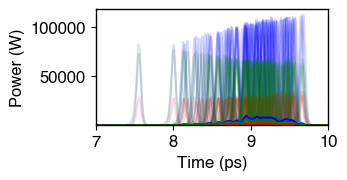

In [18]:
figure(figsize=(3,1.5))
plot(t_sto,ensemble_t_out[:,1,1,:],color="blue",alpha=0.15)
plot(t_sto,ensemble_t_out[:,2,1,:],color="red",alpha=0.15)
plot(t_sto,ensemble_t_out[:,6,1,:],color="green",alpha=0.15)
plot(t_sto,average_t_out[:,1],color="blue",alpha=1,linestyle="-")
plot(t_sto,average_t_out[:,2],color="red",alpha=1,linestyle="-")
plot(t_sto,average_t_out[:,6],color="green",alpha=1,linestyle="-")
xlabel("Time (ps)")
ylabel("Power (W)")
xlim(7,10)
ylim(1e3)
display(gcf())

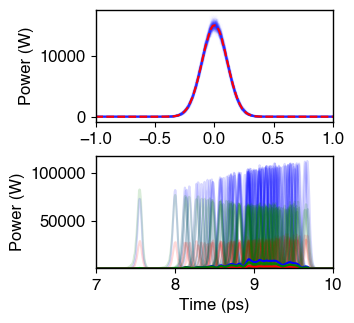

In [19]:
rc("font", family="Helvetica", size=12)
rc("axes", titlesize=13, labelsize=12, linewidth=1)
rc("xtick", labelsize=12)
rc("ytick", labelsize=12)
rc("legend", fontsize=9.5)

fig_figure4, axes_figure4 = subplots(2, 1, figsize=(3, 3))
ax_figure4_in, ax_figure4_out = axes_figure4

for ii in 1:120
    ax_figure4_in.plot(t_sto, ensemble_t_in[:, 1:1, 1, ii];
        color="blue", alpha=0.01)
end
ax_figure4_in.plot(t_sto, average_t_in[:, 1:1];
    color="red", alpha=1, linestyle="--")
ax_figure4_in.set_ylabel("Power (W)")
ax_figure4_in.set_xlim(-1, 1)

ax_figure4_out.plot(t_sto, ensemble_t_out[:, 1, 1, :];
    color="blue", alpha=0.15)
ax_figure4_out.plot(t_sto, ensemble_t_out[:, 2, 1, :];
    color="red", alpha=0.15)
ax_figure4_out.plot(t_sto, ensemble_t_out[:, 6, 1, :];
    color="green", alpha=0.15)
ax_figure4_out.plot(t_sto, average_t_out[:, 1];
    color="blue", alpha=1, linestyle="-")
ax_figure4_out.plot(t_sto, average_t_out[:, 2];
    color="red", alpha=1, linestyle="-")
ax_figure4_out.plot(t_sto, average_t_out[:, 6];
    color="green", alpha=1, linestyle="-")
ax_figure4_out.set_xlabel("Time (ps)")
ax_figure4_out.set_ylabel("Power (W)")
ax_figure4_out.set_xlim(7, 10)
ax_figure4_out.set_ylim(bottom=1e3)

fig_figure4.subplots_adjust(
    left=0.19, right=0.98, bottom=0.12, top=0.98, hspace=0.30,
)

savefig(joinpath(OUTPUT_PDF_DIR, "stochastic.pdf"); bbox_inches="tight", pad_inches=0.05)

display(fig_figure4)